### 특성 공학
- 기존의 특성을 사용해 새로운 특성을 뽑아내는 작업

### 데이터 준비를 하겠습니다

In [1]:
import pandas as pd
df = pd.read_csv('https://bit.ly/perch_csv_data')

In [2]:
import numpy as np

In [3]:
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

### 문제는 데이터 프레임 형태 정답은 넘파이 배열로 되어있으니
### 문제를 넘파이 배열로 바꿔주겠다

In [4]:
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [5]:
# 데이터를 분리하겠습니다
# test_size를 지정하지 않으면 디폴트 값 0.25 들어갑니다
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = \
train_test_split(perch_full, 
                 perch_weight,
                 random_state=42)

### 특성에 관련된 내용을 추가할껀데 그 전에 어떻게 들어오는지
### 확인해보도록 하겠습니다

In [6]:
# 사이킷런의 변환기
# 특성을 만들거나 전처리하기 위한 다양한 클래스를 제공
# fit / transform

In [7]:
# 특성공학에 사용되는 패키지를 불러올껀데
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures()

In [8]:
print(poly.fit_transform([[2,3]]))

[[1. 2. 3. 4. 6. 9.]]


In [9]:
# 절편의 계수를 제거 
poly = PolynomialFeatures(include_bias=False)
print(poly.fit_transform([[2,3]]))

[[2. 3. 4. 6. 9.]]


In [10]:
# 지금 데이터 길이 / 높이 / 넓이
poly = PolynomialFeatures(include_bias=False)
train_poly = poly.fit_transform(X_train)
print(train_poly.shape)

(42, 9)


In [11]:
# get_feature_names_out() : 특성이 어떻게 만들어졌는지 확인하는 방법
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [12]:
# train의 특성이 9개가 되었니 
# test의 특성도 9개로 맞춰주자
test_poly = poly.fit_transform(X_test)
print(test_poly.shape)

(14, 9)


### 선형회귀 모델로 학습

In [13]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly,y_train)
print(lr.score(train_poly,y_train))

0.9903183436982125


In [14]:
print(lr.score(test_poly,y_test))

0.9714559911594155


In [15]:
# polynomialfeature는 디폴트 값으로 2차항을 만들어준다
# degree 라는 매개 변수를 통해 다차항도 만들어 줄 수 있다
# 5차항의 특성을 추가해보도록 하겠습니다
poly = PolynomialFeatures(degree=5, 
                          include_bias=False)

train_poly = poly.fit_transform(X_train)
test_poly = poly.fit_transform(X_test)
print(train_poly.shape)

(42, 55)


In [16]:
# 선형회귀에 다시 학습시키겠다
lr.fit(train_poly,y_train)
print(lr.score(train_poly,y_train))

0.9999999999938143


In [17]:
print(lr.score(test_poly,y_test))

-144.40744532797535


In [18]:
print(train_poly)

[[1.96000000e+01 5.14000000e+00 3.04000000e+00 ... 7.42244501e+02
  4.38992857e+02 2.59637799e+02]
 [2.20000000e+01 5.88000000e+00 3.52000000e+00 ... 1.50793507e+03
  9.02709432e+02 5.40397483e+02]
 [1.87000000e+01 5.20000000e+00 3.12000000e+00 ... 8.21240709e+02
  4.92744425e+02 2.95646655e+02]
 ...
 [2.56000000e+01 6.56000000e+00 4.24000000e+00 ... 3.28023719e+03
  2.12015331e+03 1.37034299e+03]
 [4.20000000e+01 1.28000000e+01 6.87000000e+00 ... 5.31239245e+04
  2.85126063e+04 1.53032504e+04]
 [3.45000000e+01 1.02600000e+01 6.39000000e+00 ... 2.74661189e+04
  1.71060916e+04 1.06537939e+04]]


### 스케일링
- 정규화 : 0 ~ 1 사이로 데이터를 변환
- 표준화 : 평균 0 표준편차 1 사이 값으로 보내는 것

In [19]:
# 표준화 진행시켜~
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

train_scaled = ss.fit_transform(train_poly)
test_scaled = ss.fit_transform(test_poly)

### 규제
- 훈련 데이터가 너무 과도하게 학습하지 못하도록 훼방
- 선형 회귀 모델의 경우 : 기울기(계수)의 크기를 조정
- 크게 2가지로 볼 수 있다 : 릿지(L2) / 라쏘(L1)

### 릿지랑 라쏘 차이
- 릿지
- 차이점 요약 : 어떤 종류의 패널티를 사용하고 그 결과 회귀 계수(기울기)에 어떤 영향을 미치는가?<br>

- L2 : (계수 제곱의 합)의 패널티를 손실함수에 더하는 방식
- 기울기(계수)들을 0에 가깝게 만들어준다
- 0 가깝게 만든다~ 라는 말은 특성이 살아 있는거죠
- 모든 특성이 중요하다고 생각이 들면 릿지를 쓰는게 좋다

- 라쏘
- L1 : (계수 절댓값의 합)에 비례하는 패널티를 손실함수에 더하는 방식
- 계수를 0에 가깝게 축소하는 동시에 일부 계수를 0으로 만들어준다
- 중요하지 않다고 컴퓨터가 판단하면 특성을 없애버린다

### 릿지
- 모델에 사용되는 모든 특성이 중요하다고 생각될 때 or
- 특성 간에 강한 상관관계를 가지고 있을 때

### 라쏘
- 모델에 불필요하거나 관련 없는 특성이 많다고 의심이 될 때 or
- 중요한 특성만 가지고 만들고 싶을 때

In [20]:
# 릿지를 사용해보자
from sklearn.linear_model import Ridge

# 객체
ridge = Ridge()

# 모델 학습
ridge.fit(train_scaled,y_train)

# 모델 점수 확인
print(ridge.score(train_scaled,y_train))

0.9896101671037343


In [21]:
print(ridge.score(test_scaled,y_test))

0.913373048064998


In [22]:
# 규제의 강도를 얼마만큼으로 줄꺼야??
# alpha : alpha값이 커지면 규제 강도가 커지니까 규칙이 더 완화

In [23]:
# 규제값에 따라 훈련과 테스트 점수를 확인 시각화
import matplotlib.pyplot as plt
train_score = []
test_score = []

# for문을 돌면서 규제강도(alpha) 값에 따른 점수를 저장
alpha_list = [0.001, 0.01, 0.1, 1 ,10 ,100]

for alpha in alpha_list:
    # 릿지 모델을 만들껀데
    ridge = Ridge(alpha = alpha)
    # 릿지 모델 훈련
    ridge.fit(train_scaled,y_train)
    # 훈련 점수와 테스트 점수를 저장
    train_score.append(ridge.score(train_scaled,y_train))
    test_score.append(ridge.score(test_scaled,y_test))

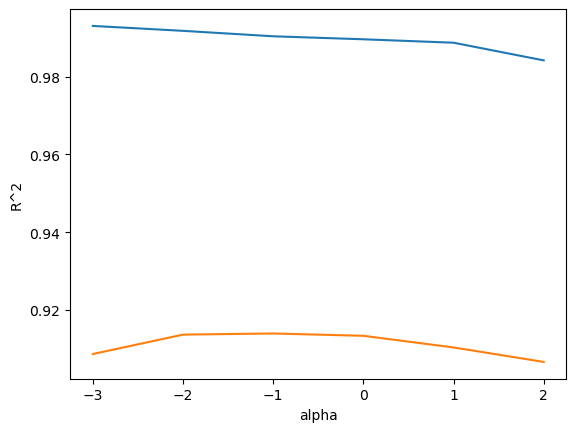

In [24]:
# 그래프를 그릴껀데~~
# 이 상태 그대로 그리면 문제점이 있습니다
# log를 사용해보자
# numpy에서 log지원 np.log() / np.log10()
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [25]:
rigde = Ridge(alpha=0.01)
ridge.fit(train_scaled,y_train)
print(ridge.score(train_scaled,y_train))
print(ridge.score(test_scaled,y_test))

0.9841843235774494
0.9066557822179537


### 라쏘

In [26]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_scaled,y_train)
print(lasso.score(train_scaled,y_train))
print(lasso.score(test_scaled,y_test))

0.989789897208096
0.9140673433424168


In [29]:
# 에러가 발생하는 이유 :라쏘 모델은 최적의 계수를 찾기 위해 
# 반복적인 계산을 수행하는데 반복 횟수가 부족할 때
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 라쏘 모델 생성
    # max_iter : 반복적인 계산을 몇 번 할꺼야??
    lasso = Lasso(alpha = alpha, max_iter=10000)
    # 라쏘 모델 훈련
    lasso.fit(train_scaled,y_train)
    # train test 점수를 저장
    train_score.append(lasso.score(train_scaled,y_train))
    test_score.append(lasso.score(test_scaled,y_test))

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


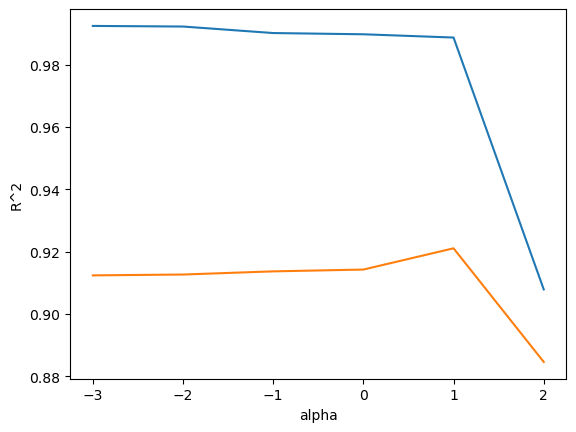

In [32]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

In [33]:
lasso = Lasso(alpha = 10)
lasso.fit(train_scaled,y_train)
print(lasso.score(train_scaled,y_train))
print(lasso.score(test_scaled,y_test))

0.9888067471131867
0.920615372493506


In [34]:
# 계수가 몇 개 0이 되었는 지 확인
print(np.sum(lasso.coef_ == 0))

40


In [ ]:
넓이라는 건 무게에 많은 영향을 안준다~
고로 c에 0을 넣어주겠다
무게 = a X 길이 + b X 높이 + c X 넓이 + d

In [39]:
df = pd.read_csv('data/boston.csv')

In [40]:
df.head(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98,24.0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


### 컬럼의 의미들

- CRIM : 지역별 범죄 발생률
- ZN : 25000평방피트를 초과하는 거주 지역의 비율
- INDUS : 비상업 지역 넓이 비율
- CHAS : 찰스강에 대한 변수(강의 경계 위치 1 아니면 0)
- NOX : 일산화탄소 농도
- RM : 거주할 수 있는 방 개수
- AGE : 1940년 이전에 건축된 소유 주택의 비율
- DIS : 5개 주요 고용센터까지의 가중 거리
- RAD : 고속도로 접근 용이도
- TAX : 10000달러 당 재산세율
- PTRATIO : 지역의 교사와 학생 수 비율
- B : 지역 흑인 거주 비율
- LSTAT : 하위 계층의 비율
- MEDV : 본인 소유의 주택 가격

In [ ]:
특성 공학 : 규칙을 강화 -> 과소적합
규제 : 규칙을 완화 -> 과대적합